# Basic Spatial Analysis
In this notebook, we will learn how to
- create geometries
- perform measurements
- compute for spatial relationships
- perform spatial operators between objects

In [1]:
import sqlite3
import matplotlib.pyplot as plt
import pandas as pd
from shapely.wkt import loads
from shapely.geometry import Point, LineString, Polygon

In [ ]:
directory = "T6-gsa/Session_3-4/"

## 1. Create Objects using Shapely

In [3]:
# Create Point Objects
p1 = Point(121.0203, 14.5516)
p2 = Point(121.0244, 14.5547)
p3 = Point(121.0437, 14.5495)

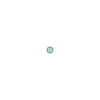

In [4]:
p2

In [ ]:
print (p2)

POINT (121.0244 14.5547)


In [6]:
# Create Line Objects
l1 = LineString([[0, 1], [0, 2], [3, 4]])
l2 = LineString(((2, 0), (3, 1), (2, 1), (3, 0)))
l3 = LineString([[121.0203, 14.5516], [121.0244, 14.5547]])

In [7]:
print (l3)

LINESTRING (121.0203 14.5516, 121.0244 14.5547)


In [8]:
# Create Polygons
poly1 = Polygon([[4, 0], [5, 1], [5, 5]])

In [9]:
print (poly1)

POLYGON ((4 0, 5 1, 5 5, 4 0))


In [10]:
l1.xy

(array('d', [0.0, 0.0, 3.0]), array('d', [1.0, 2.0, 4.0]))

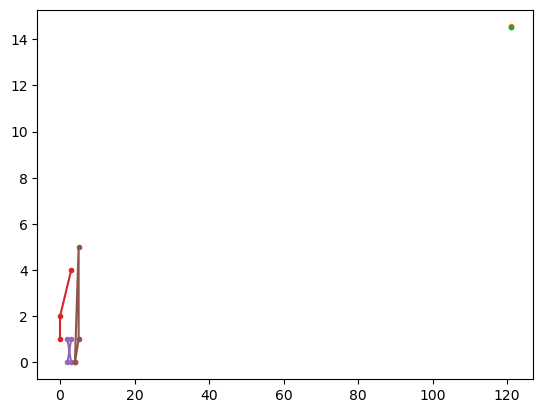

In [11]:
# Visualize the Objects using Matplotlib
plt.plot(*p1.xy, marker='.')
plt.plot(*p2.xy, marker='.')
plt.plot(*p3.xy, marker='.')
plt.plot(*l1.xy, marker='.')
plt.plot(*l2.xy, marker='.')
plt.plot(*poly1.exterior.xy, marker='.')

## 2. SQL Review

In [12]:
# Establish a connection to our sample database "map.sqlite"
conn = sqlite3.connect(directory + 'map.sqlite')
conn.enable_load_extension(True)
conn.load_extension('mod_spatialite')

In [13]:
# How do you show all tables from the DB?
cursor = conn.cursor()
cursor.execute("""
    SELECT name
    FROM sqlite_master
    WHERE type='table';
""")
tables = cursor.fetchall()
print(tables)           

[('geometry_columns',), ('spatial_ref_sys',), ('addresses',), ('sqlite_sequence',), ('buildings',), ('water_areas',), ('water_lines',), ('roads',), ('stations',), ('amenity_points',), ('amenity_polygons',), ('trees',), ('tunnels',), ('bridges',), ('landcover',), ('power_lines',), ('power_line_columns',)]


In [14]:
conn.execute('''
SELECT name
FROM sqlite_master
WHERE type = 'table';
''').fetchall()

[('geometry_columns',),
 ('spatial_ref_sys',),
 ('addresses',),
 ('sqlite_sequence',),
 ('buildings',),
 ('water_areas',),
 ('water_lines',),
 ('roads',),
 ('stations',),
 ('amenity_points',),
 ('amenity_polygons',),
 ('trees',),
 ('tunnels',),
 ('bridges',),
 ('landcover',),
 ('power_lines',),
 ('power_line_columns',)]

In [15]:
df_tables = pd.read_sql('''
SELECT name
FROM sqlite_master
WHERE type = 'table'
''', conn)
df_tables

,name
0,geometry_columns
1,spatial_ref_sys
2,addresses
3,sqlite_sequence
4,buildings
5,water_areas
6,water_lines
7,roads
8,stations
9,amenity_points


In [16]:
# Show first five rows for the table amenity_points
df = pd.read_sql('''
SELECT *
FROM amenity_points
LIMIT 5
''', conn)
df.columns

Index(['ogc_fid', 'GEOMETRY', 'osm_id', 'highway', 'amenity', 'name',
       'operator', 'sport', 'addr:housenumber', 'leisure', 'office', 'shop',
       'tourism', 'addr:housename', 'brand', 'covered', 'public_transport',
       'junction', 'cuisine', 'addr:street', 'addr:postcode', 'alt_name',
       'branch', 'addr:city', 'email', 'country', 'name:en', 'target',
       'opening_hours', 'garmin:description', 'outdoor_seating',
       'service:bicycle:bicycle_sales_and_service', 'addr:floor', 'level',
       'website', 'addr:street:corner', 'short_name', 'healthcare', 'atm',
       'addr:place', 'fee', 'capacity', 'parking', 'rooms', 'contact:phone',
       'contact:email', 'addr:country', 'internet_access:fee', 'stars',
       'smoking', 'internet_access', 'brand:wikidata', 'brand:wikipedia',
       'phone', 'repair', 'postal_code', 'bus', 'takeaway', 'wheelchair',
       'facebook', 'drink:espresso', 'drink:filter_coffee', 'official_name',
       'fax', 'old_name', 'description', 's

In [17]:
df

,ogc_fid,GEOMETRY,osm_id,highway,amenity,name,operator,sport,addr:housenumber,leisure,...,facebook,drink:espresso,drink:filter_coffee,official_name,fax,old_name,description,share_taxi,bicycle_parking,addr:unit
0,1,b'\x01\x01\x00\x00\x00\xa6\xb38\x08\xdf@^@hi]Y...,27049508,traffic_signals,None,None,None,None,None,None,...,None,None,None,None,None,None,None,None,None,None
1,2,b'\x01\x01\x00\x00\x00\xc2s\xa5T\xf8@^@\xd5V\x...,6687031928,traffic_signals,None,None,None,None,None,None,...,None,None,None,None,None,None,None,None,None,None
2,3,b'\x01\x01\x00\x00\x00\x86\xdcV\xc4\xfa@^@B\x1...,6687031926,traffic_signals,None,None,None,None,None,None,...,None,None,None,None,None,None,None,None,None,None
3,4,b'\x01\x01\x00\x00\x00~\x9aI\x8a\xfe@^@\x17\xd...,313868248,traffic_signals,None,None,None,None,None,None,...,None,None,None,None,None,None,None,None,None,None
4,5,b'\x01\x01\x00\x00\x00\xfd\x8e<k\x12A^@\xc2\x1...,7016175494,None,restaurant,Azami,None,None,None,None,...,None,None,None,None,None,None,None,None,None,None


In [18]:
pd.read_sql('''
SELECT *
FROM amenity_points
''', conn)

,ogc_fid,GEOMETRY,osm_id,highway,amenity,name,operator,sport,addr:housenumber,leisure,...,facebook,drink:espresso,drink:filter_coffee,official_name,fax,old_name,description,share_taxi,bicycle_parking,addr:unit
0,1,b'\x01\x01\x00\x00\x00\xa6\xb38\x08\xdf@^@hi]Y...,27049508,traffic_signals,None,None,None,None,None,None,...,None,None,None,None,None,None,None,None,None,None
1,2,b'\x01\x01\x00\x00\x00\xc2s\xa5T\xf8@^@\xd5V\x...,6687031928,traffic_signals,None,None,None,None,None,None,...,None,None,None,None,None,None,None,None,None,None
2,3,b'\x01\x01\x00\x00\x00\x86\xdcV\xc4\xfa@^@B\x1...,6687031926,traffic_signals,None,None,None,None,None,None,...,None,None,None,None,None,None,None,None,None,None
3,4,b'\x01\x01\x00\x00\x00~\x9aI\x8a\xfe@^@\x17\xd...,313868248,traffic_signals,None,None,None,None,None,None,...,None,None,None,None,None,None,None,None,None,None
4,5,b'\x01\x01\x00\x00\x00\xfd\x8e<k\x12A^@\xc2\x1...,7016175494,None,restaurant,Azami,None,None,None,None,...,None,None,None,None,None,None,None,None,None,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
281,282,b'\x01\x01\x00\x00\x00zV\xd2\x8aoA^@\xe2\x9e\x...,1689432571,None,fast_food,Bagsik Bagnet,None,None,None,None,...,None,None,None,None,None,None,None,None,None,None
282,283,b'\x01\x01\x00\x00\x00\xf8!\xcarmA^@w\xa9l\xb3...,1689432577,None,restaurant,Ineng's Special BBQ,None,None,None,None,...,None,None,None,None,None,None,None,None,None,None
283,284,b'\x01\x01\x00\x00\x00k\xe9v\x9b\\A^@\xa0\xa92...,4507869290,None,parking_entrance,None,None,None,None,None,...,None,None,None,None,None,None,None,None,None,None
284,285,b'\x01\x01\x00\x00\x00TZ\xda\x04sA^@\x00\n\xe4...,6707563156,None,cafe,Yi Fang,None,None,101,None,...,None,None,None,None,None,None,None,None,None,None


In [19]:
# Show amenity points with names
pd.read_sql('''
SELECT *
FROM amenity_points
WHERE name IS NOT NULL
''', conn)

,ogc_fid,GEOMETRY,osm_id,highway,amenity,name,operator,sport,addr:housenumber,leisure,...,facebook,drink:espresso,drink:filter_coffee,official_name,fax,old_name,description,share_taxi,bicycle_parking,addr:unit
0,5,b'\x01\x01\x00\x00\x00\xfd\x8e<k\x12A^@\xc2\x1...,7016175494,None,restaurant,Azami,None,None,None,None,...,None,None,None,None,None,None,None,None,None,None
1,6,b'\x01\x01\x00\x00\x000\x1d)\x11\x17A^@!0 \xc5...,6688502276,None,parking_entrance,One Corporate Plaza Basement Parking,None,None,None,None,...,None,None,None,None,None,None,None,None,None,None
2,7,b'\x01\x01\x00\x00\x00\x92\x15\rc\x1cA^@Nk\x89...,659639221,None,bank,BDO,BDO Unibank,None,None,None,...,None,None,None,None,None,None,None,None,None,None
3,8,b'\x01\x01\x00\x00\x00\x13-\xd4\xf5\x1fA^@\xc5...,6679558277,None,None,Elorde Top Team,None,boxing;kickboxing;weightlifting,843,fitness_centre,...,None,None,None,None,None,None,None,None,None,None
4,9,"b'\x01\x01\x00\x00\x00\xe17\xcf""%A^@\xe8=\x84\...",4515017489,None,embassy,Bulgarian Consulate,None,None,None,None,...,None,None,None,None,None,None,None,None,None,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
235,281,b'\x01\x01\x00\x00\x00&\xe5I-oA^@\xea\xe3F6\xf...,6589495563,None,None,Said Sew,None,None,None,None,...,None,None,None,None,None,None,None,None,None,None
236,282,b'\x01\x01\x00\x00\x00zV\xd2\x8aoA^@\xe2\x9e\x...,1689432571,None,fast_food,Bagsik Bagnet,None,None,None,None,...,None,None,None,None,None,None,None,None,None,None
237,283,b'\x01\x01\x00\x00\x00\xf8!\xcarmA^@w\xa9l\xb3...,1689432577,None,restaurant,Ineng's Special BBQ,None,None,None,None,...,None,None,None,None,None,None,None,None,None,None
238,285,b'\x01\x01\x00\x00\x00TZ\xda\x04sA^@\x00\n\xe4...,6707563156,None,cafe,Yi Fang,None,None,101,None,...,None,None,None,None,None,None,None,None,None,None


In [20]:
# What are the amenity types in the amenity_points table?
pd.read_sql('''
SELECT amenity_points.amenity
FROM amenity_points
GROUP BY amenity_points.amenity
''', conn)

,amenity
0,None
1,atm
2,bank
3,bar
4,bicycle_parking
5,bureau_de_change
6,cafe
7,cinema
8,coworking_space
9,dentist


In [21]:
pd.read_sql('''
SELECT DISTINCT amenity_points.amenity
FROM amenity_points
''', conn)

,amenity
0,None
1,restaurant
2,parking_entrance
3,bank
4,embassy
5,cafe
6,fast_food
7,dentist
8,bar
9,pharmacy


In [22]:
pd.read_sql('''
SELECT DISTINCT amenity_points."addr:city"
FROM amenity_points
''', conn)

,addr:city
0,None
1,Makati
2,Makati City


#### Exercise: Rank the amenities by most frequent to least frequent.

In [23]:
# Your Code Here
pd.read_sql('''
SELECT amenity_points.amenity, count(*) as quantity
FROM amenity_points
GROUP BY amenity
ORDER BY quantity DESC
''', conn)

,amenity,quantity
0,None,109
1,restaurant,59
2,bank,51
3,cafe,16
4,fast_food,11
5,parking_entrance,7
6,bar,6
7,parking,4
8,embassy,4
9,bicycle_parking,3


In [24]:
pd.read_sql('''
            SELECT amenity_points.amenity, count(*) as "number of amenities"
            FROM amenity_points
            GROUP BY 1
            ORDER BY 2 DESC
            ''', conn)

,amenity,number of amenities
0,None,109
1,restaurant,59
2,bank,51
3,cafe,16
4,fast_food,11
5,parking_entrance,7
6,bar,6
7,parking,4
8,embassy,4
9,bicycle_parking,3


## 3. Creating Geometries Through SQL
We will now create points, lines, and polygons using SQL commands
- ST_MakePoint / MakePoint
- ST_MakeLine / MakeLine
- ST_MakePolygon / MakePolygon
- ST_GeomFromText

In [25]:
# Creating Points
pd.read_sql('''
            SELECT MakePoint(121.0203, 14.5516) as "Greenbelt Point"
            ''', conn)

,Greenbelt Point
0,b'\x00\x01\x00\x00\x00\x00\xf7\x06_\x98LA^@|\x...


In [26]:
pd.read_sql('''
            SELECT MakePoint(121.0203, 14.5516, 4326) as "Greenbelt Point"
            ''', conn)

,Greenbelt Point
0,b'\x00\x01\xe6\x10\x00\x00\xf7\x06_\x98LA^@|\x...


In [27]:
## Use ST_AsText to make the geometry Human Readable
pd.read_sql('''
            SELECT ST_AsText(MakePoint(121.0203, 14.5516, 4326)) as "Greenbelt Point"
            ''', conn)

,Greenbelt Point
0,POINT(121.0203 14.5516)


In [28]:
# If we want to use our shapely object, we use:
pd.read_sql('''
            SELECT ST_AsText(GeomFromText(?)) as "Greenbelt Point"
            ''', conn, params=[p1.wkt])

,Greenbelt Point
0,POINT(121.0203 14.5516)


In [29]:
# We lose info on the SRID, we use SetSRID to add SR information
pd.read_sql('''
            SELECT ST_AsText(SetSRID(GeomFromText(?), 4326)) as "Greenbelt Point"
            ''', conn, params = [p1.wkt])

,Greenbelt Point
0,POINT(121.0203 14.5516)


In [30]:
# Creating Lines
pd.read_sql('''
            SELECT ST_AsText(MakeLine(MakePoint(121.0203, 14.5516),MakePoint(121.0244, 14.5547))) as "Greenbelt to Ayala Triangle"
            ''', conn)

,Greenbelt to Ayala Triangle
0,"LINESTRING(121.0203 14.5516, 121.0244 14.5547)"


In [31]:
# Use our shapely object to create a line
pd.read_sql('''
            SELECT ST_AsText(GeomFromText(?)) as "Greenbelt to Ayala Triangle"
            ''', conn, params = [l3.wkt])

,Greenbelt to Ayala Triangle
0,"LINESTRING(121.0203 14.5516, 121.0244 14.5547)"


#### Exercise: Create a Polygon going from (0,0) to (0,1) to (1,0) and back to (0,0)


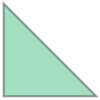

In [ ]:
# Your Code Here
poly = Polygon([[0,0],[0,1],[1,0]])
poly

In [33]:
pd.read_sql('''
            SELECT ST_AsText(GeomFromText(?)) as Polygon
            ''', conn, params = [poly.wkt])

,Polygon
0,"POLYGON((0 0, 0 1, 1 0, 0 0))"


##  4. Measurements

### Proximity
- ST_Distance
- ST_DWithin / PtDistWithin

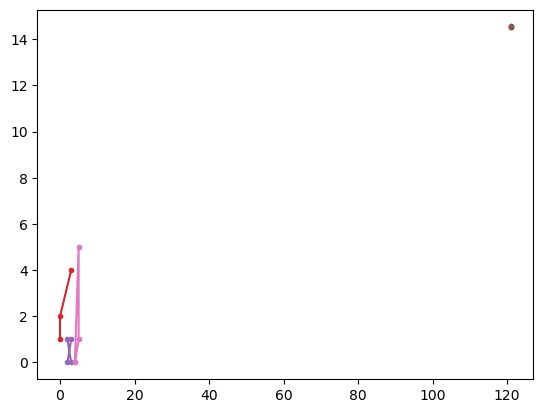

In [34]:
plt.plot(*p1.xy, marker='.')
plt.plot(*p2.xy, marker='.')
plt.plot(*p3.xy, marker='.')
plt.plot(*l1.xy, marker='.')
plt.plot(*l2.xy, marker='.')
plt.plot(*l3.xy, marker='.')
plt.plot(*poly1.exterior.xy, marker='.')

In [35]:
# Use ST_Distance to compute distance between p1 and p2
pd.read_sql('''
            SELECT ST_Distance(ST_GeomFromText(?), ST_GeomFromText(?)) as dist
            ''', conn, params = [p1.wkt, p2.wkt])

,dist
0,0.00514


In [36]:
# What is the distance between p1 and l1?
pd.read_sql('''
            SELECT ST_Distance(ST_GeomFromText(?),ST_GeomFromText(?)) as dist
            ''', conn, params = [p1.wkt, l1.wkt])

,dist
0,118.491044


In [37]:
# ST_DWithin / PTDistWithin returns a boolean if two points are within a specified distance from each other
pd.read_sql('''
            SELECT PTDistWithin(ST_GeomFromText(?),ST_GeomFromText(?),0.05) as within
            ''', conn, params=[p1.wkt, p2.wkt])

,within
0,1


In [38]:
# What is the distance between l1 and l2?
pd.read_sql('''
            SELECT ST_Distance(ST_GeomFromText(?),ST_GeomFromText(?)) as dist
            ''', conn, params = [l2.wkt, l1.wkt])

,dist
0,1.941451


### Measurements
 - ST_NPoints
 - ST_Length / GLength
 - ST_Area
 - ST_Perimeter

In [39]:
# How many points are there in l1?
pd.read_sql('''
            SELECT ST_NPoints(ST_GeomFromText(?)) as points
            ''', conn, params = [l1.wkt])

,points
0,3


In [40]:
# What is the total length of l2?
pd.read_sql('''
            SELECT ST_Length(ST_GeomFromText(?)) as length
            ''', conn, params = [l2.wkt])

,length
0,3.828427


In [41]:
# What is the area of poly1?
pd.read_sql('''
            SELECT ST_Area(ST_GeomFromText(?)) as area
            ''', conn, params = [poly1.wkt])

,area
0,2.0


In [42]:
# What is the perimeter of poly1?
pd.read_sql('''
            SELECT ST_Perimeter(ST_GeomFromText(?)) as perimeter
            ''', conn, params = [poly1.wkt])

,perimeter
0,10.513233


## 5. Spatial Relationship
 - ST_IsSimple

In [43]:
# What is ST_IsSimple? (use l1 then l2 to check)
pd.read_sql('''
            SELECT ST_IsSimple(ST_GeomFromText(?)) as Simple
            ''', conn, params = [l1.wkt])

,Simple
0,1


In [44]:
pd.read_sql('''
            SELECT ST_IsSimple(ST_GeomFromText(?)) as Simple
            ''', conn, params = [l2.wkt])

,Simple
0,0


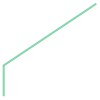

In [45]:
l1

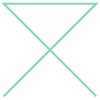

In [46]:
l2

#### Add more polygons

In [47]:
poly2 = Polygon([[1, 1], [1, 4], [4, 4], [4, 1]])
poly3 = Polygon([[2, 2], [2, 3], [4.75, 3], [4.75, 2]])
poly4 = Polygon([[-1, 2], [-1, 3], [4.75, 3], [4.75, 2]])
poly5 = Polygon([[1.5, 1.5], [1.5, 2.5], [2.5, 2.5], [2.5, 1.5]])

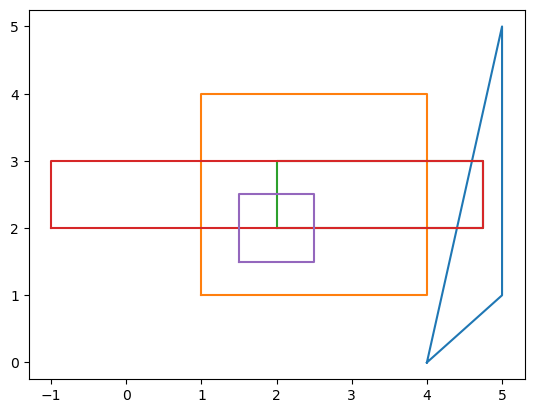

In [48]:
plt.plot(*poly1.exterior.xy)
plt.plot(*poly2.exterior.xy)
plt.plot(*poly3.exterior.xy)
plt.plot(*poly4.exterior.xy)
plt.plot(*poly5.exterior.xy)

#### Exercise: Use the five polygons to determine the functionalites of the following functions:
- ST_Disjoint
- ST_Intersects
- ST_Overlaps
- ST_Within / ST_Contains

In [49]:
# Your Code Here
pd.read_sql('''
            SELECT ST_Disjoint(ST_GeomFromText(?), ST_GeomFromText(?)) as Disjoint
            ''', conn, params = [poly3.wkt, poly4.wkt])

,Disjoint
0,0


In [50]:
pd.read_sql('''
            SELECT ST_Intersects(ST_GeomFromText(?), ST_GeomFromText(?)) as Intersects
            ''', conn, params = [poly2.wkt, poly3.wkt])

,Intersects
0,1


In [51]:
pd.read_sql('''
            SELECT ST_Overlaps(ST_GeomFromText(?), ST_GeomFromText(?)) as Overlaps
            ''', conn, params = [poly2.wkt, poly3.wkt])

,Overlaps
0,1


In [52]:
pd.read_sql('''
            SELECT ST_Within(GeomFromText(?), GeomFromText(?)) as Within
            ''', conn, params = [poly4.wkt, poly5.wkt])

,Within
0,0


In [53]:
pd.read_sql('''
            SELECT ST_Contains(GeomFromText(?), GeomFromText(?)) as Contains
            ''', conn, params = [poly2.wkt, poly4.wkt])

,Contains
0,0


#### Other Functions
- ST_Equals
- ST_Touches

In [54]:
pd.read_sql('''
            SELECT ST_Equals(GeomFromText(?), GeomFromText(?)) as Equals
            ''', conn, params = [poly1.wkt, poly1.wkt])

,Equals
0,1


In [55]:
pd.read_sql('''
            SELECT ST_Touches(GeomFromText(?), GeomFromText(?)) as Touches
            ''', conn, params = [poly1.wkt, poly3.wkt])

,Touches
0,0


## 6. Spatial Operators
- ST_Union
- ST_Intersection
- ST_Difference
- ST_SymDifference
- ST_Buffer

In [56]:
# Code Here
pd.read_sql('''
            SELECT ST_AsText(ST_Union(ST_GeomFromText(?), ST_GeomFromText(?))) as "Union"
            ''', conn, params = [poly2.wkt, poly4.wkt])

,Union
0,"POLYGON((1 2, -1 2, -1 3, 1 3, 1 4, 4 4, 4 3, ..."


In [57]:
pd.read_sql('''
            SELECT ST_AsText(ST_Intersection(ST_GeomFromText(?), ST_GeomFromText(?))) as "Intersection"
            ''', conn, params = [poly2.wkt, poly4.wkt])

,Intersection
0,"POLYGON((1 3, 4 3, 4 2, 1 2, 1 3))"


In [58]:
pd.read_sql('''
            SELECT ST_AsText(ST_Difference(ST_GeomFromText(?), ST_GeomFromText(?))) as "Difference"
            ''', conn, params = [poly2.wkt, poly4.wkt])

,Difference
0,"MULTIPOLYGON(((1 2, 4 2, 4 1, 1 1, 1 2)), ((1 ..."


In [59]:
pd.read_sql('''
            SELECT ST_AsText(ST_SymDifference(ST_GeomFromText(?), ST_GeomFromText(?))) as "Sym Difference"
            ''', conn, params = [poly2.wkt, poly4.wkt])

,Sym Difference
0,"MULTIPOLYGON(((1 2, 4 2, 4 1, 1 1, 1 2)), ((1 ..."


In [60]:
pd.read_sql('''
            SELECT ST_AsText(ST_Buffer(ST_GeomFromText(?), ST_GeomFromText(?))) as "Buffer"
            ''', conn, params = [poly1.wkt, poly4.wkt])

,Buffer
0,None
